# OCT Random Forest Classification Method 2

---

## Importing Libraries

In [1]:
import cv2 as cv
import os
from skimage.feature import hog
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Define Helper Functions

In [2]:
def extract_hog_features(image):
    # Calculate HOG features
    hog_features = hog(image, orientations=9, pixels_per_cell=(8, 8),
    cells_per_block=(2, 2), visualize=True)
    return hog_features[0]

## Loading the Image Data and Extracting HOG (Histogram Oriented Feature) Data

In [3]:
count_max = 204

img_path = r'mar+may_2024_threshold/'
files = os.listdir(img_path)

max_decay = 0
max_dead = 0
max_live = 0

X=[]
y=[]

live_c = 0
dead_c = 0
decay_c = 0

for filename in files:
    #temp1 = filename[-6:]
    #if temp1 == '25.npy':
        #continue
    category = ''
    if 'decay' in filename and max_decay <= count_max:
        continue
        category = 'decay'
        if max_decay == count_max:
            continue
        max_decay += 1
        decay_c += 1
    elif 'dead' in filename and max_dead <= count_max:
        category = 'dead'
        if max_dead == count_max:
            continue
        max_dead += 1
        dead_c += 1
    elif 'live' in filename and max_live <= count_max:
        category = 'live'
        if max_live == count_max:
            continue
        max_live += 1
        live_c += 1
    print(filename)

    image = np.load(img_path + filename)
    image_res = cv.resize(image, (128, 128))

    hog_features = extract_hog_features(image_res)
    print(len(hog_features))
    X.append(hog_features)
    y.append(category)

90_dead49.npy
8100
251_dead0.npy
8100
192_live0.npy
8100
109_live0.npy
8100
257_live25.npy
8100
206_live49.npy
8100
224_live25.npy
8100
157_live0.npy
8100
54_live5.npy
8100
132_dead25.npy
8100
259_live49.npy
8100
67_live0.npy
8100
250_dead0.npy
8100
193_live0.npy
8100
244_dead49.npy
8100
267_live14.npy
8100
34_live49.npy
8100
245_live0.npy
8100
215_dead25.npy
8100
198_live49.npy
8100
156_live0.npy
8100
143_dead0.npy
8100
22_live49.npy
8100
203_dead25.npy
8100
108_live0.npy
8100
73_live25.npy
8100
268_dead49.npy
8100
196_live25.npy
8100
170_live25.npy
8100
226_dead0.npy
8100
38_live0.npy
8100
152_live49.npy
8100
233_live0.npy
8100
66_live0.npy
8100
88_live0.npy
8100
108_live25.npy
8100
76_live49.npy
8100
263_dead49.npy
8100
246_live0.npy
8100
166_live5.npy
8100
13_live49.npy
8100
190_live0.npy
8100
13_live0.npy
8100
60_live49.npy
8100
62_dead33.npy
8100
232_dead25.npy
8100
29_live49.npy
8100
88_live25.npy
8100
157_live25.npy
8100
175_live49.npy
8100
225_dead0.npy
8100
124_live25.npy
810

## Set up Training Data (Reserve 30% of data for testing)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, stratify=y)

## Defining Random Forest Parameters for GridSearch Tuning (Hyperparameter Tuning)

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
param_dist = {
    "max_depth"         : [1, 5, 10, 15, 20, 25, 30],
    "n_estimators"      : [5,10,50,100,110,120,200],
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": [2, 4, 8],
    "bootstrap" : [True, False],
    "ccp_alpha" : [0.0, 0.01, 0.02]
}
clf = GridSearchCV(
   RandomForestClassifier(random_state=0, class_weight='balanced'), param_dist, cv=5
)

## Begin Training

In [ ]:
import time
start = time.perf_counter()
clf = clf.fit(X_train, y_train)
print("Best estimator found by grid search:")
print(clf.best_score_)
print(clf.best_estimator_.score(X_train, y_train))
print(clf.best_estimator_.score(X_test, y_test))
end = time.perf_counter()
print(end - start)

## Dump Trained Model to File

In [ ]:
import joblib
joblib.dump(clf, 'OCT_RF_classifier_method_2_all_data_threshold.pkl')

In [5]:
import joblib
job = joblib.load('OCT_RF_classifier_method_2_all_data.pkl')
print(job.best_score_)
print(job.best_estimator_.score(X_train, y_train))
print(job.best_estimator_.score(X_test, y_test))

0.6947368421052632
0.6912280701754386
0.6585365853658537


/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.7.0 when u

In [8]:
print(job.best_estimator_.get_params())

{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 4, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}


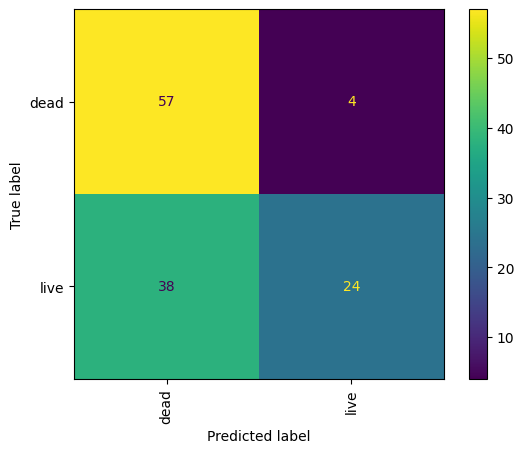

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
ConfusionMatrixDisplay.from_estimator(
    job.best_estimator_, X_test, y_test, xticks_rotation="vertical"
)

In [6]:
job = joblib.load('OCT_RF_classifier_method_2_all_data_threshold.pkl')
print(job.best_score_)
print(job.best_estimator_.score(X_train, y_train))
print(job.best_estimator_.score(X_test, y_test))

0.6877192982456141
0.9122807017543859
0.8617886178861789


/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.7.0 when u

In [8]:
print(job.best_estimator_.get_params())

{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 25, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 4, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}


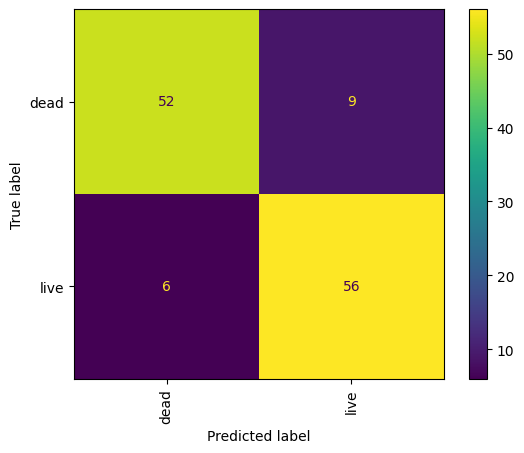

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
ConfusionMatrixDisplay.from_estimator(
    job.best_estimator_, X_test, y_test, xticks_rotation="vertical"
)